In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pd.set_option('display.float_format', lambda x: '%.10f' % x)

## Đọc file

In [ ]:
# Dữ liệu đã được chọn lọc, xử lý, loại bỏ các thuộc tính
df = pd.read_csv('/content/drive/MyDrive/ds304/gold_data_drop6.csv')
## Dữ liệu gốc chưa được chọn lọc, xử lý, loại bỏ các thuộc tính
df_origin = pd.read_csv('/content/drive/MyDrive/ds304/processed_data.csv')

## Chia tập dữ liệu

In [ ]:
# Tập dữ liệu đã được xử lý
target = 'Point'
X = df.drop(target, axis=1)
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Shape of train - processed:', X_train.shape)
print('Shape of test- processed:', X_test.shape)

Shape of train - processed: (3123, 50)
Shape of test- processed: (781, 50)


In [ ]:
X_origin = df_origin.drop([target], axis=1)
y_origin = df_origin[target]
X_train_origin, X_test_origin, y_train_origin, y_test_origin = train_test_split(X_origin, y_origin, test_size=0.2, random_state=42)
print('Shape of train - origin:', X_train_origin.shape)
print('Shape of test - origin:', X_test_origin.shape)

Shape of train - origin: (3104, 29)
Shape of test - origin: (777, 29)


In [ ]:
# Hàm tính R2 Adjust
def r2_adjusted(r2, n, p):
  r2_adjusted = 1 - (1 - r2) * (n - 1) / (n - p - 1)
  return r2_adjusted

## Linear Regression

### Tập dữ liệu đã được xử lý

#### Mô hình với tham số mặc định và đánh giá bằng cross-validation

In [ ]:
linear_model = LinearRegression()

_mae_train = -cross_val_score(linear_model, X_train, y_train, cv=10, scoring='neg_mean_absolute_error')
_r2_train = cross_val_score(linear_model, X_train, y_train, cv=10, scoring='r2')

#### kết quả đánh giá bằng cross-validation

In [ ]:
print('Result on train data:\n')
print('   Mean MAE:', _mae_train.mean())
print('   MAE standard deviation:', _mae_train.std())
print('\n   Mean R2:', _r2_train.mean())
print('   R2 standard deviation:', _r2_train.std())
print('\n   R2 adjusted:', r2_adjusted(_r2_train.mean(), X_train.shape[0], X_train.shape[1]))

Result on train data:

   Mean MAE: 0.18383983468093948
   MAE standard deviation: 0.013051907142191009

   Mean R2: 0.8611995574053151
   R2 standard deviation: 0.06386071279634573

   R2 adjusted: 0.8589404356182921


### Tập dữ liệu gốc

#### Mô hình với tham số mặc định và đánh giá bằng cross-validation

In [ ]:
linear_model_origin = LinearRegression()

_mae_train_origin = -cross_val_score(linear_model_origin, X_train_origin, y_train_origin, cv=10, scoring='neg_mean_absolute_error')
_r2_train_origin = cross_val_score(linear_model_origin, X_train_origin, y_train_origin, cv=10, scoring='r2')

#### Kết quả đánh giá bằng cross-validation

In [ ]:
print('\nResult on train origin data:\n')
print('   Mean MAE:', _mae_train_origin.mean())
print('   MAE standard deviation:', _mae_train_origin.std())
print('\n   Mean R2:', _r2_train_origin.mean())
print('   R2 standard deviation:', _r2_train_origin.std())
print('\n   R2 adjusted:', r2_adjusted(_r2_train_origin.mean(), X_train_origin.shape[0], X_train_origin.shape[1]))


Result on train origin data:

   Mean MAE: 0.23013576275686712
   MAE standard deviation: 0.015531025334298964

   Mean R2: 0.7631247173165132
   R2 standard deviation: 0.10962910179083284

   R2 adjusted: 0.7608900448383671


## Thực hiện dự đoán trên tập test

### Tập dữ liệu đã được xử lý

In [ ]:
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

_mae_test = mean_absolute_error(y_test, y_pred)
_r2_test = r2_score(y_test, y_pred)

#### Kết quả trên tập test

In [ ]:
print('Result on processed data:')
print('   MAE:', _mae_test)
print('   R2:', _r2_test)
print('   R2 adjusted:', r2_adjusted(_r2_test, X_test.shape[0], X_test.shape[1]))

Result on processed data:
   MAE: 0.16871673943249282
   R2: 0.8924865599636653
   R2 adjusted: 0.8851226257146013


### Tập dữ liệu gốc

In [ ]:
linear_model_origin.fit(X_train_origin, y_train_origin)
y_pred_origin = linear_model_origin.predict(X_test_origin)

_mae_test_origin = mean_absolute_error(y_test_origin, y_pred_origin)
_r2_test_origin = r2_score(y_test_origin, y_pred_origin)

#### Kết quả trên tập test

In [ ]:
print('Result on test origin data:')
print('   MAE:', _mae_test_origin)
print('   R2:', _r2_test_origin)
print('   R2 adjusted:', r2_adjusted(_r2_test_origin, X_test_origin.shape[0], X_test_origin.shape[1]))

Result on test origin data:
   MAE: 0.21488528164023735
   R2: 0.8279771202611049
   R2 adjusted: 0.8212988558535709


### So sánh

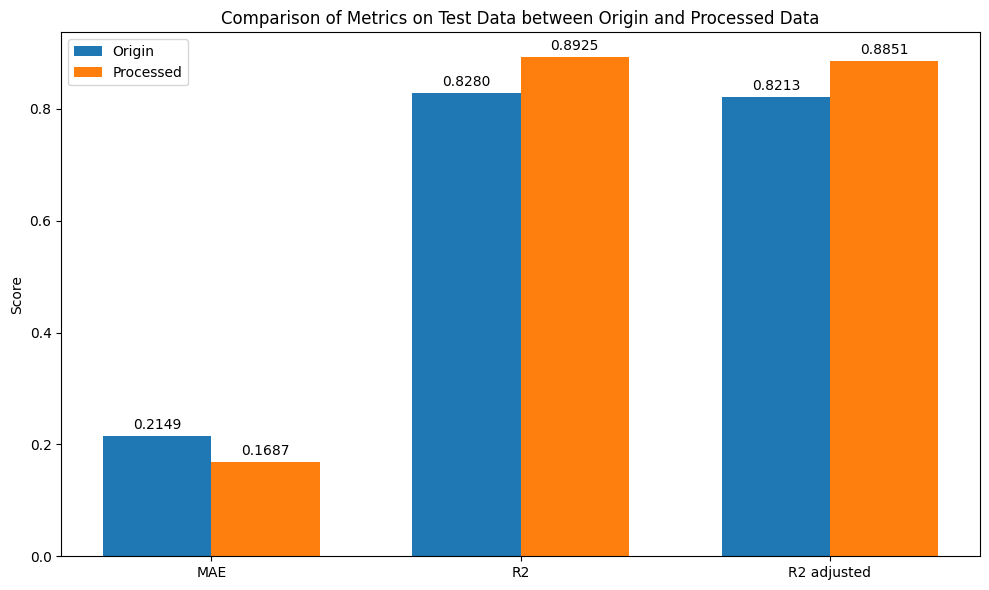

In [ ]:
metrics_test = ['MAE', 'R2', 'R2 adjusted']
origin_values_test = [_mae_test_origin, _r2_test_origin, r2_adjusted(_r2_test_origin, X_test_origin.shape[0], X_test_origin.shape[1])]
processed_values_test = [_mae_test, _r2_test, r2_adjusted(_r2_test, X_test.shape[0], X_test.shape[1])]

x_test = np.arange(len(metrics_test))  # the label locations
width_test = 0.35  # the width of the bars

fig_test, ax_test = plt.subplots(figsize=(10, 6))
rects1_test = ax_test.bar(x_test - width_test/2, origin_values_test, width_test, label='Origin')
rects2_test = ax_test.bar(x_test + width_test/2, processed_values_test, width_test, label='Processed')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax_test.set_ylabel('Score')
ax_test.set_title('Comparison of Metrics on Test Data between Origin and Processed Data')
ax_test.set_xticks(x_test)
ax_test.set_xticklabels(metrics_test)
ax_test.legend()

ax_test.bar_label(rects1_test, padding=3, fmt='%.4f')
ax_test.bar_label(rects2_test, padding=3, fmt='%.4f')

fig_test.tight_layout()

plt.show()

## Tìm bộ siêu tham số tối ưu bằng gridSearch

### Tập dữ liệu đã được xử lý

In [ ]:
param_grid = {
    'fit_intercept': [True],
    'positive': [True, False]
}
_grid_search = GridSearchCV(estimator=LinearRegression(), param_grid=param_grid, cv=10,
                           scoring='neg_mean_absolute_error', n_jobs=-1)

_grid_search.fit(X_train, y_train)
_best_linear_model = _grid_search.best_estimator_
_best_mae_train = -_grid_search.best_score_

print('Best score:')
print('   MAE: ', _best_mae_train)
print('   Parameters: ', _grid_search.best_params_)

Best score:
   MAE:  0.18383983468093948
   Parameters:  {'fit_intercept': True, 'positive': False}


#### Huấn luyện và đánh giá bằng bộ siêu tham số tối ưu tìm được

In [ ]:
y_pred_tuned = _best_linear_model.predict(X_test)
_mae_test_tuned = mean_absolute_error(y_test, y_pred_tuned)
_r2_test_tuned = r2_score(y_test, y_pred_tuned)

In [ ]:
print('Result on test data after tuned:')
print('   Mean Absolute Error:', _mae_test_tuned)
print('   R2:', _r2_test_tuned)
print('   R2 adjusted:', r2_adjusted(_r2_test_tuned, X_test.shape[0], X_test.shape[1]))

Result on test data after tuned:
   Mean Absolute Error: 0.16871673943249282
   R2: 0.8924865599636653
   R2 adjusted: 0.8851226257146013


### Tập dữ liệu gốc

In [ ]:
param_grid_origin = {
    'fit_intercept': [True],
    'positive': [True, False]
}
_grid_search_origin = GridSearchCV(estimator=LinearRegression(), param_grid=param_grid_origin, cv=10,
                           scoring='neg_mean_absolute_error', n_jobs=-1)

_grid_search_origin.fit(X_train_origin, y_train_origin)
_best_linear_model_origin = _grid_search_origin.best_estimator_
_best_mae_train_origin = -_grid_search_origin.best_score_

print('\nBest score on origin data:')
print('   MAE: ', _best_mae_train_origin)
print('   Parameters: ', _grid_search_origin.best_params_)


Best score on origin data:
   MAE:  0.23013576275686712
   Parameters:  {'fit_intercept': True, 'positive': False}


#### Huấn luyện và đánh giá mô hình bằng bộ siêu tham số tối ưu tìm được

In [ ]:
y_pred_tuned_origin = _best_linear_model_origin.predict(X_test_origin)
_mae_test_tuned_origin = mean_absolute_error(y_test_origin, y_pred_tuned_origin)
_r2_test_tuned_origin = r2_score(y_test_origin, y_pred_tuned_origin)
print('Result on test origin data after tuned:')
print('   Mean Absolute Error:', _mae_test_tuned_origin)
print('   R2:', _r2_test_tuned_origin)
print('   R2 adjusted:', r2_adjusted(_r2_test_tuned_origin, X_test_origin.shape[0], X_test_origin.shape[1]))

Result on test origin data after tuned:
   Mean Absolute Error: 0.21488528164023735
   R2: 0.8279771202611049
   R2 adjusted: 0.8212988558535709


### So sánh

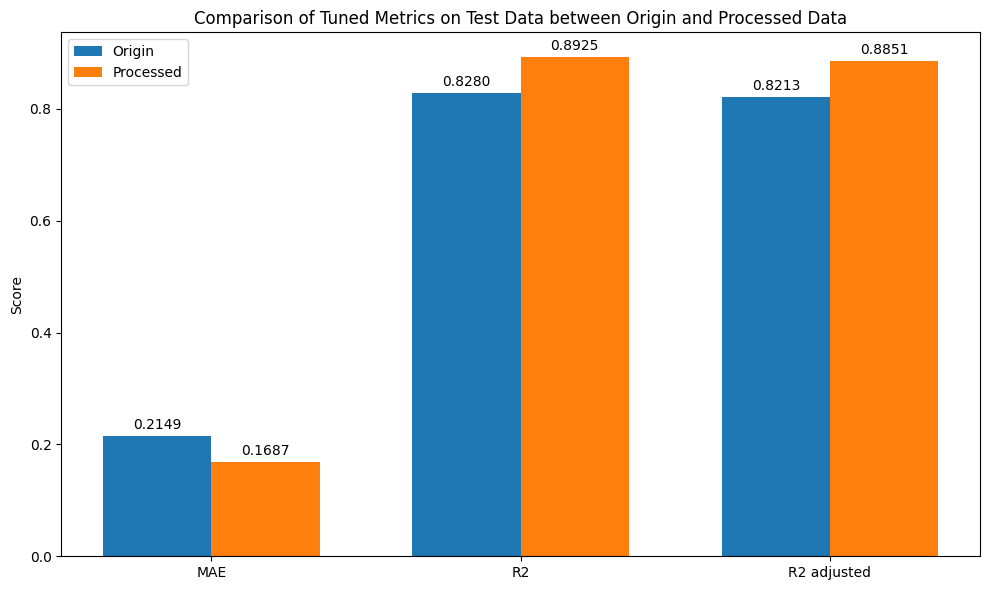

In [ ]:
metrics_tuned = ['MAE', 'R2', 'R2 adjusted']
origin_values_tuned = [_mae_test_tuned_origin, _r2_test_tuned_origin, r2_adjusted(_r2_test_tuned_origin, X_test_origin.shape[0], X_test_origin.shape[1])]
processed_values_tuned = [_mae_test_tuned, _r2_test_tuned, r2_adjusted(_r2_test_tuned, X_test.shape[0], X_test.shape[1])]

x_tuned = np.arange(len(metrics_tuned))  # the label locations
width_tuned = 0.35  # the width of the bars

fig_tuned, ax_tuned = plt.subplots(figsize=(10, 6))
rects1_tuned = ax_tuned.bar(x_tuned - width_tuned/2, origin_values_tuned, width_tuned, label='Origin')
rects2_tuned = ax_tuned.bar(x_tuned + width_tuned/2, processed_values_tuned, width_tuned, label='Processed')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax_tuned.set_ylabel('Score')
ax_tuned.set_title('Comparison of Tuned Metrics on Test Data between Origin and Processed Data')
ax_tuned.set_xticks(x_tuned)
ax_tuned.set_xticklabels(metrics_tuned)
ax_tuned.legend()

ax_tuned.bar_label(rects1_tuned, padding=3, fmt='%.4f')
ax_tuned.bar_label(rects2_tuned, padding=3, fmt='%.4f')

fig_tuned.tight_layout()

plt.show()

# Kiểm định ý nghĩa thống kê mô hình - ANOVA F-test


## Tập dữ liệu đã được xử lý

In [ ]:
X_train_const = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_const).fit()
print(ols_model.summary())
# xuất ra file excel

                            OLS Regression Results                            
Dep. Variable:                  Point   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     390.1
Date:                Sun, 06 Jul 2025   Prob (F-statistic):               0.00
Time:                        02:36:12   Log-Likelihood:                -697.29
No. Observations:                3123   AIC:                             1497.
Df Residuals:                    3072   BIC:                             1805.
Df Model:                          50                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

## Tập dữ liệu gốc

In [ ]:
X_train_origin_const = sm.add_constant(X_train_origin)
ols_model_origin = sm.OLS(y_train_origin, X_train_origin_const).fit()
print(ols_model_origin.summary().tables[0])

                            OLS Regression Results                            
Dep. Variable:                  Point   R-squared:                       0.773
Model:                            OLS   Adj. R-squared:                  0.771
Method:                 Least Squares   F-statistic:                     360.8
Date:                Sun, 06 Jul 2025   Prob (F-statistic):               0.00
Time:                        02:36:12   Log-Likelihood:                -1139.7
No. Observations:                3104   AIC:                             2339.
Df Residuals:                    3074   BIC:                             2521.
Df Model:                          29                                         
Covariance Type:            nonrobust                                         


# Kiểm định độ khớp của mô hình với dữ liệu - Lack of Fit F-test

In [ ]:
# kiểm tra xem dữ có replicate không
num_duplicates = df.duplicated().sum()
print("Số lượng bản sao trong dữ liệu:", num_duplicates)

Số lượng bản sao trong dữ liệu: 0


--> Không đủ điều kiện để thực hiện Lack of Fit F-test